https://psicode.org/psi4manual/master/api/psi4.core.Wavefunction.html#psi4.core.Wavefunction

In [1]:
import pickle, os, numpy as np

In [2]:
dataroot = "/root/limlab01/kaistai/25DFT/data/QM9_sample"
datalist = sorted([os.path.join(dataroot, fname) for fname in os.listdir(dataroot)])

In [3]:
with open(datalist[1], 'rb') as f:
	data = pickle.load(f)
	data = data[list(data.keys())[0]]

In [4]:
def print_dict_structure(d, indent=0, print_type=False, index_path=""):
    """Recursively print dictionary structure with hierarchical numbering."""
    if isinstance(d, dict):
        for idx, k in enumerate(d.keys(), 1):
            # Build current index path
            current_index = f"{index_path}-{idx}" if index_path else str(idx)
            type_info = f" [{type(d[k]).__name__}]" if print_type else ""
            print("  " * indent + f"{current_index}. {k}{type_info}")
            print_dict_structure(d[k], indent + 1, print_type, current_index)
    elif isinstance(d, list):
        type_info = f" [list of {type(d[0]).__name__}]" if d and print_type else ""
        print("  " * indent + f"[list] (len={len(d)}){type_info}")
        if d and isinstance(d[0], (dict, list)):
            print_dict_structure(d[0], indent + 1, print_type, index_path)
    else:
        pass
        # if print_type:
        #     print("  " * indent + f"[{type(d).__name__}]")

print_dict_structure(data, print_type=True)

1. energy [float]
2. total_time [float]
3. energy_time [float]
4. gradient_time [float]
5. wavefunction [dict]
  5-1. molecule [dict]
    5-1-1. provenance [dict]
      5-1-1-1. creator [str]
      5-1-1-2. routine [str]
      5-1-1-3. version [str]
    5-1-2. units [str]
    5-1-3. geom [ndarray]
    5-1-4. elea [ndarray]
    5-1-5. elez [ndarray]
    5-1-6. elem [ndarray]
    5-1-7. mass [ndarray]
    5-1-8. real [ndarray]
    5-1-9. elbl [ndarray]
    5-1-10. fragment_separators [list]
      [list] (len=0)
    5-1-11. molecular_charge [float]
    5-1-12. fragment_charges [list]
      [list] (len=1) [list of float]
    5-1-13. molecular_multiplicity [int]
    5-1-14. fragment_multiplicities [list]
      [list] (len=1) [list of int]
    5-1-15. fix_com [bool]
    5-1-16. fix_orientation [bool]
  5-2. matrix [dict]
    5-2-1. Ca [ndarray]
    5-2-2. Cb [ndarray]
    5-2-3. Da [ndarray]
    5-2-4. Db [ndarray]
    5-2-5. Fa [ndarray]
    5-2-6. Fb [ndarray]
    5-2-7. H [ndarray]
    5-

In [5]:
data

{'energy': -56.59637669798353,
 'total_time': 6.127204418182373,
 'energy_time': 4.5299530029296875e-06,
 'gradient_time': 6.126387357711792,
 'wavefunction': {'molecule': {'provenance': {'creator': 'QCElemental',
    'routine': 'qcelemental.molparse.from_string',
    'version': '0.29.0'},
   'units': 'Angstrom',
   'geom': array([-0.031611  ,  0.02116096,  0.06033786,  0.02607252, -0.99040158,
          -0.0296031 ,  0.92460442,  0.35579841, -0.0309837 , -0.51146268,
           0.34058534, -0.77776855]),
   'elea': array([14,  1,  1,  1]),
   'elez': array([7, 1, 1, 1]),
   'elem': array(['N', 'H', 'H', 'H'], dtype='<U1'),
   'mass': array([14.003074  ,  1.00782503,  1.00782503,  1.00782503]),
   'real': array([ True,  True,  True,  True]),
   'elbl': array(['', '', '', ''], dtype='<U1'),
   'fragment_separators': [],
   'molecular_charge': 0.0,
   'fragment_charges': [0.0],
   'molecular_multiplicity': 1,
   'fragment_multiplicities': [1],
   'fix_com': False,
   'fix_orientation': F

In [6]:
data["wavefunction"]["molecule"]

{'provenance': {'creator': 'QCElemental',
  'routine': 'qcelemental.molparse.from_string',
  'version': '0.29.0'},
 'units': 'Angstrom',
 'geom': array([-0.031611  ,  0.02116096,  0.06033786,  0.02607252, -0.99040158,
        -0.0296031 ,  0.92460442,  0.35579841, -0.0309837 , -0.51146268,
         0.34058534, -0.77776855]),
 'elea': array([14,  1,  1,  1]),
 'elez': array([7, 1, 1, 1]),
 'elem': array(['N', 'H', 'H', 'H'], dtype='<U1'),
 'mass': array([14.003074  ,  1.00782503,  1.00782503,  1.00782503]),
 'real': array([ True,  True,  True,  True]),
 'elbl': array(['', '', '', ''], dtype='<U1'),
 'fragment_separators': [],
 'molecular_charge': 0.0,
 'fragment_charges': [0.0],
 'molecular_multiplicity': 1,
 'fragment_multiplicities': [1],
 'fix_com': False,
 'fix_orientation': False}

In [7]:
# 0-1: finding number of orbitals
import pyscf.gto

orbital_list = {}

def get_orbital_list(atomic_symbol, basis="def2tzvppd"):
    if basis not in orbital_list:   
        orbital_list[basis] = {}
    if atomic_symbol in orbital_list[basis]:
        return orbital_list[basis][atomic_symbol]
    else:
        orbital_data = pyscf.gto.basis.load(basis, atomic_symbol)
        orb_list = []
        orbstr_list = []
        orbstr = "spdfghi"
        for orb in orbital_data:
            orb_rank = orb[0]
            orb_list.append(orb_rank + 1)
            orb_idx = orb_list.count(orb_rank + 1) + orb_rank - 1
            orbstr_list.append(f"{orb_idx+1}{orbstr[orb_rank]}")
        orbital_list[atomic_symbol] = orb_list, orbstr_list
        return orb_list, orbstr_list

def get_orbital_list_from_atomic_symbol(atomic_symbols, basis="def2tzvppd"):
    tot_orb_list = []
    tot_orbstr_list = []
    for sym in atomic_symbols:
        orb_list, orbstr_list = get_orbital_list(sym, basis)
        tot_orb_list.extend(orb_list)
        tot_orbstr_list.extend(orbstr_list)
    return tot_orb_list, tot_orbstr_list

In [ ]:
# 0. Molecule geometry & energy, forces
atomic_number = data["wavefunction"]["molecule"]["elez"]
atomic_symbol = data["wavefunction"]["molecule"]["elem"]
# num_elec = data["wavefunction"]["molecule"]["elea"]
pos = data["wavefunction"]["molecule"]["geom"].reshape(-1, 3)
orb_list, orbstr_list = get_orbital_list_from_atomic_symbol(atomic_symbol)

energy = data["energy"]
forces = -data["gradient"] # force_i = - dE/dpos_i

print("Length unit:", data["wavefunction"]["molecule"]["units"])
print("pos.dtype:", pos.dtype)
print("atomic_number:", atomic_number)
print("atomic_symbol:", atomic_symbol)
print("pos:", pos)
print("energy:", energy) # E_h (atomic unit)
print("forces:", forces) # E_h/bohr (atomic unit)
print("Ham_dim:", sum(orb_list) * 2 - len(orb_list))
print(orb_list)
print(orbstr_list)

Length unit: Angstrom
pos.dtype: float64
atomic_number: [7 1 1 1]
atomic_symbol: ['N' 'H' 'H' 'H']
pos: [[-0.031611    0.02116096  0.06033786]
 [ 0.02607252 -0.99040158 -0.0296031 ]
 [ 0.92460442  0.35579841 -0.0309837 ]
 [-0.51146268  0.34058534 -0.77776855]]
energy: -56.59637669798353
forces: [[ 0.00364191 -0.00244012 -0.00693918]
 [-0.00091124  0.0031645   0.00164771]
 [-0.00326799 -0.00036879  0.00165159]
 [ 0.00053817 -0.00035663  0.00364018]]
Ham_dim: 88
[1, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 1, 1, 1, 2, 2, 2, 3, 1, 1, 1, 2, 2, 2, 3, 1, 1, 1, 2, 2, 2, 3]
['1s', '2s', '3s', '4s', '5s', '6s', '2p', '3p', '4p', '3d', '4d', '5d', '4f', '1s', '2s', '3s', '2p', '3p', '4p', '3d', '1s', '2s', '3s', '2p', '3p', '4p', '3d', '1s', '2s', '3s', '2p', '3p', '4p', '3d']


In [9]:
sum(orb_list) * 2 - len(orb_list)


88

In [10]:
get_orbital_list("N")

([1, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4],
 ['1s',
  '2s',
  '3s',
  '4s',
  '5s',
  '6s',
  '2p',
  '3p',
  '4p',
  '3d',
  '4d',
  '5d',
  '4f'])

In [11]:
# Visualize with py3Dmol
import py3Dmol

def atom_data_to_xyz(atomic_numbers, positions):
    """Convert atomic data to XYZ format string"""
    # Element symbols mapping
    element_map = {
        1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B', 6: 'C', 7: 'N', 8: 'O', 
        9: 'F', 10: 'Ne', 11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P', 
        16: 'S', 17: 'Cl', 18: 'Ar', 19: 'K', 20: 'Ca', 35: 'Br', 53: 'I'
    }
    
    # Convert Bohr to Angstrom (1 Bohr = 0.529177 Angstrom)
    # bohr_to_angstrom = 0.529177210903
    positions_angstrom = positions
    
    # Build XYZ format
    n_atoms = len(atomic_numbers)
    xyz = f"{n_atoms}\n"
    xyz += "Molecule from DFT calculation\n"
    
    for z, pos in zip(atomic_numbers, positions_angstrom):
        symbol = element_map.get(int(z), f'X{int(z)}')
        xyz += f"{symbol:2s} {pos[0]:12.6f} {pos[1]:12.6f} {pos[2]:12.6f}\n"
    
    return xyz

def view_molecule_3d(atomic_numbers, positions, size=(600, 400), style='stick', surface=False, opacity=0.5):
    """Visualize molecule in 3D using py3Dmol"""
    assert style in ('line', 'stick', 'sphere', 'cartoon')
    
    # Convert to XYZ format
    xyz_data = atom_data_to_xyz(atomic_numbers, positions)
    
    # Create viewer
    viewer = py3Dmol.view(width=size[0], height=size[1])
    viewer.addModel(xyz_data, 'xyz')
    viewer.setStyle({"stick": {"radius": 0.05}, "sphere": {"scale": 0.2}})
    
    if surface:
        viewer.addSurface(py3Dmol.SAS, {'opacity': opacity})
    
    viewer.zoomTo()
    return viewer

# Visualize the molecule
viewer = view_molecule_3d(atomic_number, pos, size=(800, 600), style='sphere', opacity=0.5)
viewer.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [12]:
# 1. Hamiltonian matrix
H = data["wavefunction"]["matrix"]["Fa"] # is the same with data["wavefunction"]["matrix"]["Fb"]
print(np.allclose(H, data["wavefunction"]["matrix"]["Fb"]))
print(H.shape)
print(H)

True
(88, 88)
[[-6.07168279e+00 -1.58152121e+01 -6.20970737e+00 ...  6.76457618e-01
  -1.62330022e-01  3.88092261e-01]
 [-1.58152121e+01 -1.03181219e+01 -5.64258208e+00 ...  7.12674831e-01
  -1.70728430e-01  4.08165944e-01]
 [-6.20970737e+00 -5.64258208e+00 -3.13442642e+00 ...  3.34132128e-01
  -7.96728835e-02  1.90470618e-01]
 ...
 [ 6.76457618e-01  7.12674831e-01  3.34132128e-01 ...  2.97264713e+00
  -4.15128621e-02 -1.21702278e-01]
 [-1.62330022e-01 -1.70728430e-01 -7.96728835e-02 ... -4.15128621e-02
   3.11940713e+00  7.57919209e-03]
 [ 3.88092261e-01  4.08165944e-01  1.90470618e-01 ... -1.21702278e-01
   7.57919209e-03  3.10448019e+00]]


In [13]:
# 2. Overlap matrix
S = data["wavefunction"]["matrix"]["S"]
print(S.shape)
print(S)

(88, 88)
[[ 1.          0.68327429  0.19009388 ... -0.01940923  0.00464822
  -0.01111261]
 [ 0.68327429  1.          0.53789416 ... -0.06501111  0.01556917
  -0.03722163]
 [ 0.19009388  0.53789416  1.         ... -0.13945717  0.03339787
  -0.07984518]
 ...
 [-0.01940923 -0.06501111 -0.13945717 ...  1.          0.
   0.        ]
 [ 0.00464822  0.01556917  0.03339787 ...  0.          1.
   0.        ]
 [-0.01111261 -0.03722163 -0.07984518 ...  0.          0.
   1.        ]]


In [14]:
# 3. Coefficient matrix
C = data["wavefunction"]["matrix"]["Ca"]
print(np.allclose(C, data["wavefunction"]["matrix"]["Cb"]))
print(C.shape)
print(C)

True
(88, 88)
[[ 4.49978135e-01  9.38019769e-02  5.87212069e-06 ... -8.17455550e-06
  -1.43048192e-07  1.40211775e+00]
 [ 6.26740593e-01  2.13279329e-01  1.36273856e-05 ...  1.72943937e-06
  -9.34257128e-07 -1.78885332e+00]
 [ 3.06236364e-02 -3.30945840e-01 -1.99130834e-05 ... -8.06006008e-04
   1.46391260e-05  1.81100461e+00]
 ...
 [ 3.24320800e-04  1.91558912e-03  2.85873433e-03 ...  3.84494933e-01
   2.55842823e-01  7.81087087e-02]
 [-6.46784256e-05 -4.41474611e-04 -4.42273027e-04 ... -1.24295961e-01
   1.87810522e-01 -1.93405637e-02]
 [ 1.54412402e-04  1.05536722e-03  1.06746511e-03 ...  3.02194848e-01
   7.52887043e-02  4.62492968e-02]]


In [15]:
# 4. epsilon
E = data["wavefunction"]["vector"]["epsilon_a"]
print(np.allclose(E, data["wavefunction"]["vector"]["epsilon_b"]))
print(E.shape)
print(E)

True
(88,)
[-14.48681488  -0.97857953  -0.56597622  -0.56593927  -0.38133693
   0.04465241   0.12103007   0.12103595   0.17084794   0.18503029
   0.18503682   0.22465045   0.22465887   0.22498133   0.29381633
   0.33346457   0.35191676   0.35191776   0.42046519   0.42046796
   0.4684906    0.50884357   0.50885136   0.64464658   0.66024017
   0.68844114   0.68847308   0.76388275   0.76391439   0.89802046
   1.02741141   1.02745602   1.15057129   1.1522419    1.26922536
   1.26927853   1.30426196   1.30428619   1.45182202   1.64790207
   1.69794921   1.69796548   1.8286245    1.82863891   2.30341565
   2.53304575   2.53305008   2.61447615   2.8311194    2.99713757
   2.99715142   3.15502863   3.31281781   3.36690159   3.36698312
   3.38154062   3.3816573    3.54873671   3.58644865   3.58647088
   3.88724595   3.92723282   3.92727148   3.99318862   3.9990574
   3.99909602   4.18853887   4.18858992   4.42907298   4.51378619
   4.51382513   4.54484998   4.80253408   4.9953386    4.99539875


In [16]:
# Basic properties:
# Prop1:  HC=SCE
HC = np.dot(H, C)
E_d = np.diag(E)
SCE = np.dot(S, np.dot(C, E_d))

if np.allclose(HC, SCE):
    print("Success: HC=SCE")
else:
    print("Failed: HC=SCE")

Success: HC=SCE


In [17]:
# Prop2: (C.T)SC = I
C_SC = np.dot(C.T, np.dot(S, C))

if np.allclose(C_SC, np.eye(C_SC.shape[0])):
    print("Success: (C.T)SC = I")
else:
    print("Failed: (C.T)SC = I")

Success: (C.T)SC = I


In [18]:
# Check density matrix is correct
num_orb = int(atomic_number.sum() / 2) # occupied orbitals
sliced_C = C[:,:int(num_orb)]
dm = np.dot(sliced_C, sliced_C.T) * 2 # multiply 2 for spin-unpolarized
np.allclose(dm, data["wavefunction"]["matrix"]["Da"] * 2)

True

In [19]:
import matplotlib.pyplot as plt

def matshow(matrix, max_val=None, max_mul=0.1, colorbar=True, frame=True, ticks=False, save_name=None, drawline=[], ratio=0.8):
    fig, ax = plt.subplots(figsize=(6*ratio,5*ratio))
    if matrix.ndim == 3:
        matrix = matrix[0]
    if max_val is None:
        max_val = abs(matrix).max() * max_mul
    im = ax.imshow(matrix, cmap='bwr',vmin=-max_val, vmax=max_val)
    if colorbar:
        fig.colorbar(im)
    if not ticks:
        ax.set_xticks([])
        ax.set_yticks([])
    
    spines_name = ['top', 'right', 'bottom', 'left']
    for spine in spines_name:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.5)
    
    if not frame: 
        for spine in spines_name:
            ax.spines[spine].set_visible(False)
    
    cur = 0
    for idx, orb_num in enumerate(drawline):
        color = 'gray'
        ls = '--'
        lw = 0.3
        if orb_num < 0:
            orb_num = -orb_num
            color = 'black'
            ls = '-'
            lw = 0.5
        cur = cur + orb_num
        ax.axhline(y=cur-0.5, color=color, linestyle=ls, linewidth=lw)
        ax.axvline(x=cur-0.5, color=color, linestyle=ls, linewidth=lw)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=600)
    plt.show()
    
    return max_val

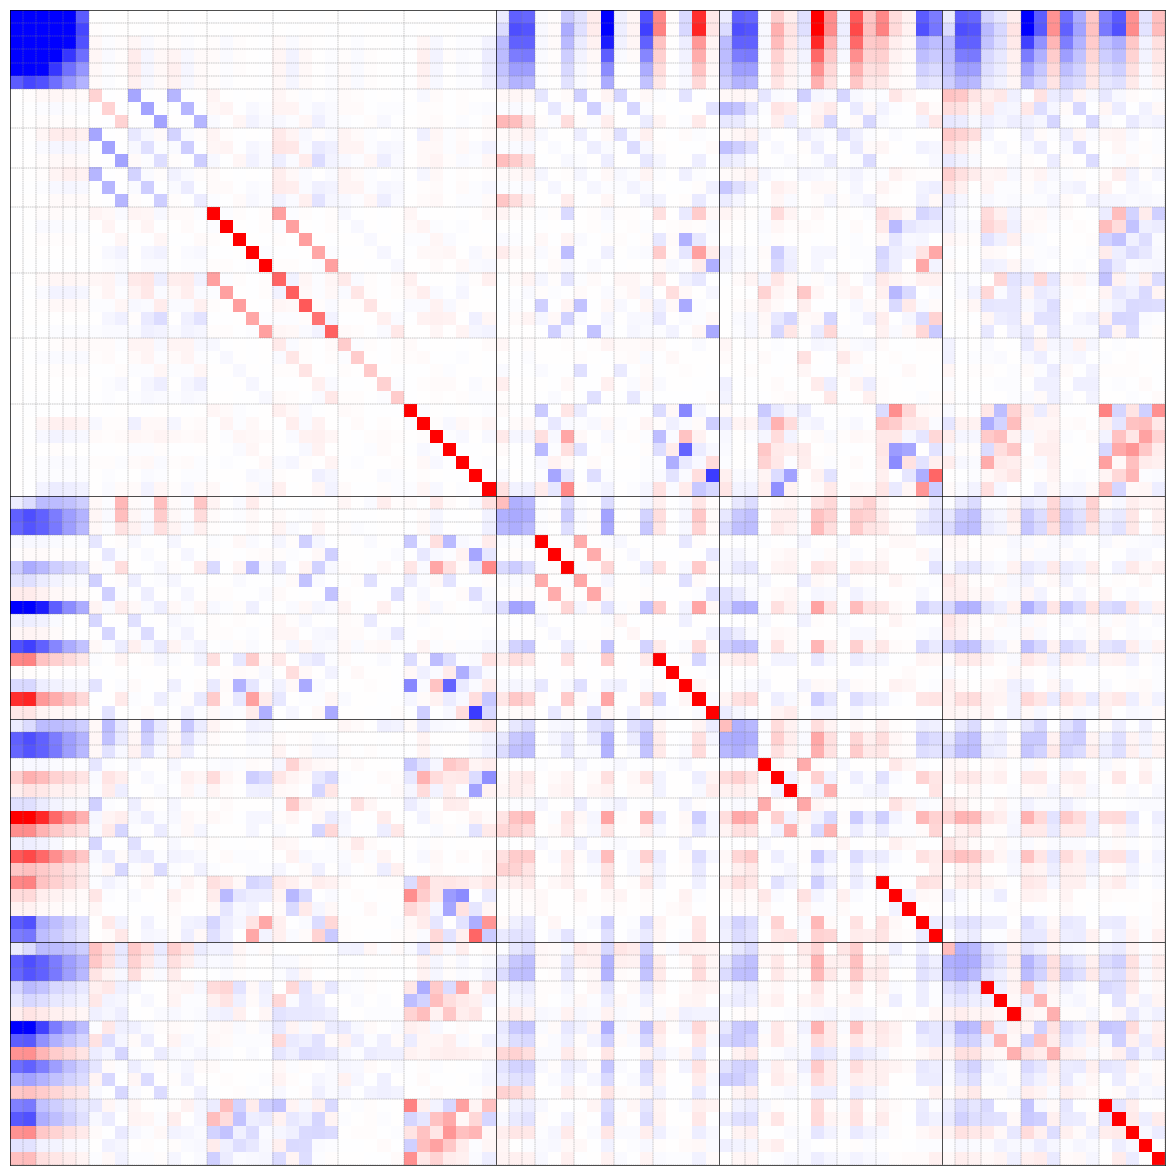

1.5815212112152301

In [20]:
orb_lines = [
    1, 1, 1, 1, 1, 1, 3, 3, 3, 5, 5, 5, -7, # N
    1, 1, 1, 3, 3, 3, -5, # H
    1, 1, 1, 3, 3, 3, -5, # H
    1, 1, 1, 3, 3, 3, 5, # H
    ]
# N : 1s, 2s, 3s, 4s, 5s, 6s, 2p, 3p, 4p, 3d, 4d, 5d, 4f
# H : 1s, 2s, 3s, 2p, 3p, 4p, 3d
# H : 1s, 2s, 3s, 2p, 3p, 4p, 3d

matshow(H, drawline=orb_lines, ratio=3, colorbar=False)

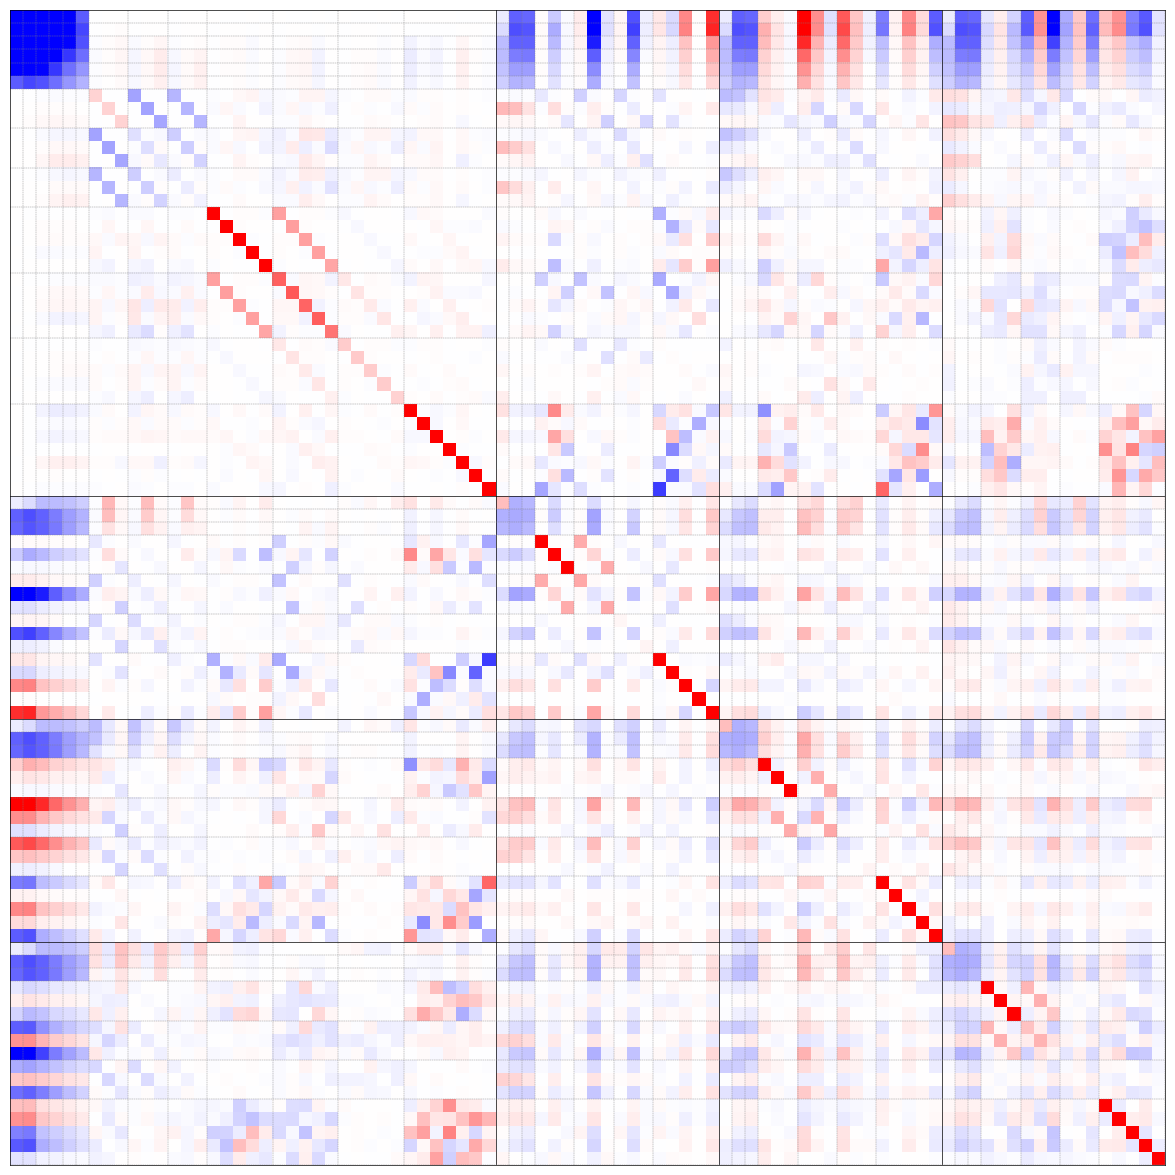

1.5815125987261078

In [ ]:
matshow(ham, drawline=orb_lines, ratio=3, colorbar=False)
# 012 ->  120
# 01234 -> 42013
# 0123456 -> 6301245

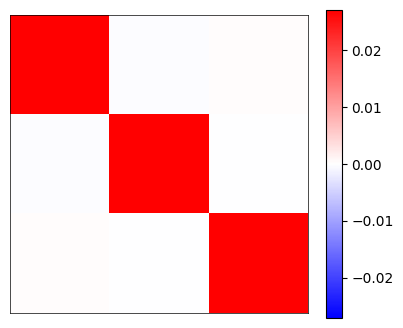

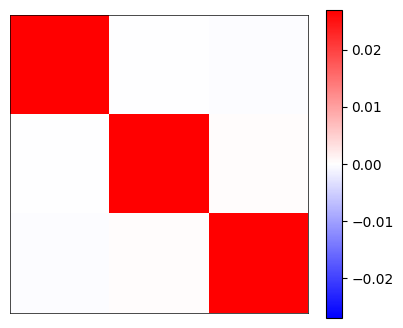

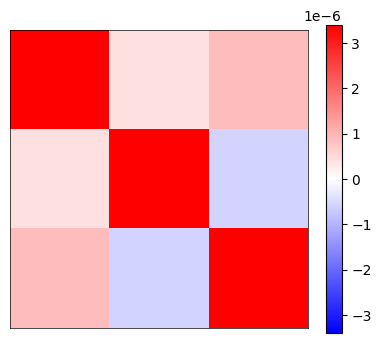

[0.27017979 0.26965591 0.26955287]
[0.26962265 0.26951893 0.27014755]
[0.26965591 0.26955287 0.27017979]


In [92]:
matshow(H[6:9,6:9])
matshow(ham[6:9,6:9])
# column 0123456 -> 6301245
# row 0123456 -> 6301245
# column change?
# Permute columns: 0123456 -> 6301245
col_perm = [1,2,0]
row_perm = col_perm
# Permute rows: 0123456 -> 6301245 
matshow(H[6:9,6:9][row_perm,:][:,col_perm]-ham[6:9,6:9])
print(H[6:9,6:9].diagonal())
print(ham[6:9,6:9].diagonal())
print(H[6:9,6:9][row_perm,:][:,col_perm].diagonal())
# [3.8990618  3.8513046  3.86662644 3.88139249 3.89668619 3.84602903
#  3.78941634]
# [3.78919428 3.89637811 3.86634781 3.89872151 3.85104777 3.88104995
#  3.84568791]


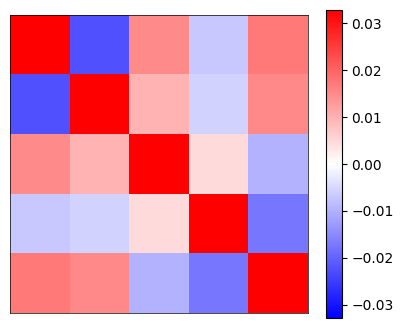

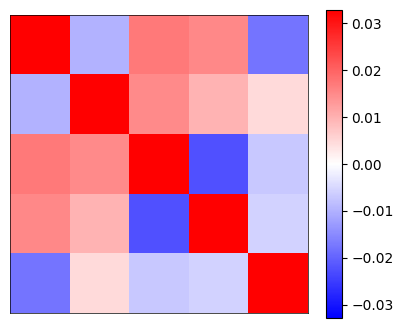

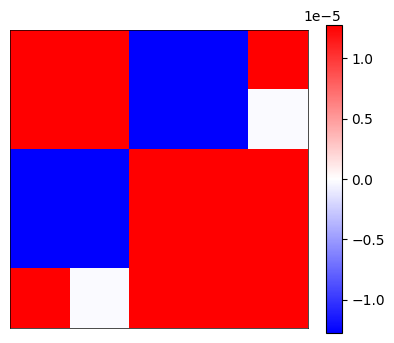

[0.31029478 0.31956167 0.32770718 0.27749192 0.31268137]
[0.3126283  0.32769143 0.3102354  0.31951217 0.27736437]
[0.31268137 0.32770718 0.31029478 0.31956167 0.27749192]


In [91]:
matshow(H[25:30,25:30])
matshow(ham[25:30,25:30])
# column 0123456 -> 6301245
# row 0123456 -> 6301245
# column change?
# Permute columns: 0123456 -> 6301245
col_perm = [4,2,0,1,3]
row_perm = col_perm
# Permute rows: 0123456 -> 6301245 
matshow(H[25:30,25:30][row_perm,:][:,col_perm]-ham[25:30,25:30])
print(H[25:30,25:30].diagonal())
print(ham[25:30,25:30].diagonal())
print(H[25:30,25:30][row_perm,:][:,col_perm].diagonal())
# [3.8990618  3.8513046  3.86662644 3.88139249 3.89668619 3.84602903
#  3.78941634]
# [3.78919428 3.89637811 3.86634781 3.89872151 3.85104777 3.88104995
#  3.84568791]


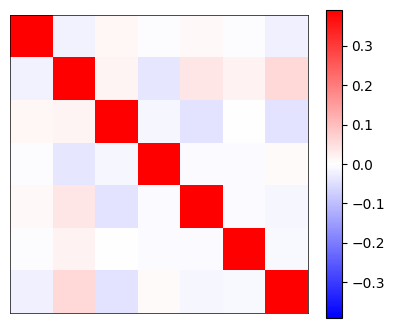

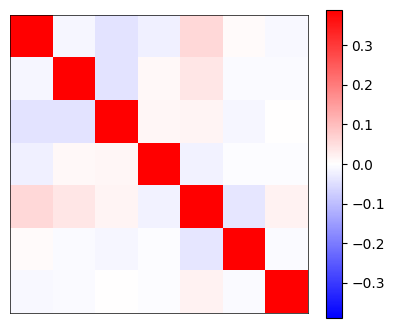

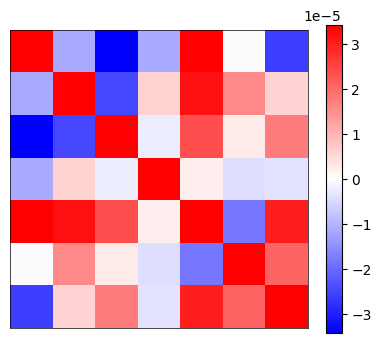

[3.8990618  3.8513046  3.86662644 3.88139249 3.89668619 3.84602903
 3.78941634]
[3.78919428 3.89637811 3.86634781 3.89872151 3.85104777 3.88104995
 3.84568791]


In [93]:
matshow(H[30:37,30:37])
matshow(ham[30:37,30:37])
# column 0123456 -> 6301245
# row 0123456 -> 6301245
# column change?
# Permute columns: 0123456 -> 6301245
col_perm = [6,4,2,0,1,3,5]
row_perm = col_perm
# Permute rows: 0123456 -> 6301245 
matshow(H[30:37,30:37][row_perm,:][:,col_perm]-ham[30:37,30:37])
print(H[30:37,30:37].diagonal())
print(ham[30:37,30:37].diagonal())
# [3.8990618  3.8513046  3.86662644 3.88139249 3.89668619 3.84602903
#  3.78941634]
# [3.78919428 3.89637811 3.86634781 3.89872151 3.85104777 3.88104995
#  3.84568791]


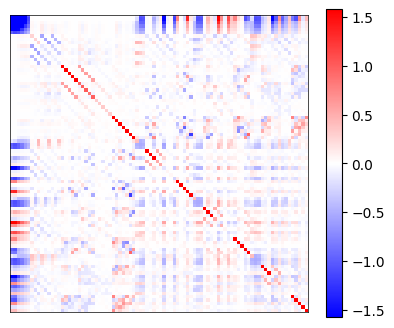

1.5815212112152301

In [94]:
matshow(H)

In [ ]:
import common.matrix_transforms as mt

AttributeError: module 'common.matrix_transforms' has no attribute 'transform_matrix'

In [101]:
convention_dict = mt.get_convention_dict()

In [ ]:
from argparse import Namespace
convention_dict = {
    "psi4_def2-tzvppd_to_pyscf": Namespace(
        atom_to_orbitals_map={
            1:  'ssspppd', # H (3s + 3p + 1d) = 3 + 9 + 5 = 17
            6:  'sssssspppdddf', # C  (6s + 3p + 3d + 1f) = 6 + 9 + 15 + 7 = 37
            7:  'sssssspppdddf', # N  (6s + 3p + 3d + 1f) = 6 + 9 + 15 + 7 = 37
            8:  'ssssssppppdddf', # O (6s + 4p + 3d + 1f) = 6 + 12 + 15 + 7 = 40
            9:  'ssssssppppdddf', # F (6s + 4p + 3d + 1f) = 6 + 12 + 15 + 7 = 40
        },
        orbital_idx_map={
            's': [0],
            'p': [1, 2, 0],
            'd': [0, 1, 2, 3, 4],
            'f': [6,4,2,0,1,3,5]
        },
        orbital_sign_map={
            's': [1],
            'p': [1, 1, 1],
            'd': [1, 1, 1, 1, 1],
            'f': [1, 1, 1, 1, 1, 1, 1],
        },
        orbital_order_map={
            1: list(range(7)),
            6: list(range(13)),
            7: list(range(13)),
            8: list(range(14)),
            9: list(range(14)),
        },
        max_block_size= 40, # 6s + 4p + 3d + 1f = 6 + 12 + 15 + 7 = 40
    ),
    'pyscf_def2-tzvp_to_e3nn': Namespace(
        atom_to_orbitals_map={
            1:  'sssp', # H
            6:  'ssssspppddf', # C
            7:  'ssssspppddf', # N
            8:  'ssssspppddf', # O
            9:  'ssssspppddf', # F
            15: 'ssssspppppddf', # P
            16: 'ssssspppppddf', # S
            17: 'ssssspppppddf', # Cl
        },
        orbital_idx_map={
            's': [0],
            'p': [1, 2, 0],
            'd': [0, 1, 2, 3, 4],
            'f': [0, 1, 2, 3, 4, 5, 6],
        },
        orbital_sign_map={
            's': [1],
            'p': [1, 1, 1],
            'd': [1, 1, 1, 1, 1],
            'f': [1, 1, 1, 1, 1, 1, 1],
        },
        orbital_order_map={
            1:  [0, 1, 2, 3],   
            6:  list(range(11)),
            7:  list(range(11)),
            8:  list(range(11)),
            9:  list(range(11)),
            15: list(range(13)),
            16: list(range(13)),
            17: list(range(13)),
        },
        max_block_size= 37, # 5s + 5p + 2d + 1f = 5 + 15 + 10 + 7 = 37
    ),
    "pyscf_631G_to_e3nn": Namespace(
        # 6-31G basis set convention used by PySCF
        # p orbitals: [px, py, pz] -> reordered to [pz, px, py] for compatibility
        atom_to_orbitals_map={
            1: "ss",
            6: "ssspp",
            7: "ssspp",
            8: "ssspp",
            9: "ssspp",
        },
        orbital_idx_map={
            "s": [0],
            "p": [1, 2, 0],   # p: [pz, px, py]
            "d": [0, 1, 2, 3, 4]
            },
        orbital_sign_map={
            "s": [1],
            "p": [1, 1, 1],
            "d": [1, 1, 1, 1, 1],
        },
        orbital_order_map={
            1: [0, 1],           # H: 2 orbitals (s, s)
            6: [0, 1, 2, 3, 4],  # C: 5 orbitals (s, s, s, p, p)
            7: [0, 1, 2, 3, 4],  # N: 5 orbitals (s, s, s, p, p)
            8: [0, 1, 2, 3, 4],  # O: 5 orbitals (s, s, s, p, p)
            9: [0, 1, 2, 3, 4],  # F: 5 orbitals (s, s, s, p, p)
        },
        max_block_size=9, # 3s + 2p = 3 + 6 = 9
    ),
    "pyscf_def2svp_to_e3nn": Namespace(
        # def2-SVP basis set convention used by PySCF
        # p orbitals: [px, py, pz] -> reordered to [py, pz, px] for compatibility
        atom_to_orbitals_map={
            1: "ssp",      # H: 3 orbitals (s, s, p)
            6: "sssppd",   # C: 6 orbitals (s, s, s, p, p, d)
            7: "sssppd",   # N: 6 orbitals (s, s, s, p, p, d)
            8: "sssppd",   # O: 6 orbitals (s, s, s, p, p, d)
            9: "sssppd",   # F: 6 orbitals (s, s, s, p, p, d)
        },
        orbital_idx_map={
            "s": [0],
            "p": [1, 2, 0],
            "d": [0, 1, 2, 3, 4],
        },  # p: [py, pz, px]
        orbital_sign_map={
            "s": [1],
            "p": [1, 1, 1],
            "d": [1, 1, 1, 1, 1],
        },
        orbital_order_map={
            1: [0, 1, 2],      # H: 3 orbitals (s, s, p)
            6: [0, 1, 2, 3, 4, 5],  # C: 6 orbitals (s, s, s, p, p, d)
            7: [0, 1, 2, 3, 4, 5],  # N: 6 orbitals (s, s, s, p, p, d)
            8: [0, 1, 2, 3, 4, 5],  # O: 6 orbitals (s, s, s, p, p, d)
            9: [0, 1, 2, 3, 4, 5],  # F: 6 orbitals (s, s, s, p, p, d)
        },
        max_block_size= 14, # 3s + 2p + 1d = 3 + 6 + 5 = 14
    ),
    'e3nn_to_pyscf_def2-tzvp': Namespace(
        atom_to_orbitals_map={
            1:  'sssp', # H
            6:  'ssssspppddf', # C
            7:  'ssssspppddf', # N
            8:  'ssssspppddf', # O
            9:  'ssssspppddf', # F
            15: 'ssssspppppddf', # P
            16: 'ssssspppppddf', # S
            17: 'ssssspppppddf', # Cl
        },
        orbital_idx_map={
            's': [0],
            'p': [2, 0, 1],
            'd': [0, 1, 2, 3, 4],
            'f': [0, 1, 2, 3, 4, 5, 6],
        },
        orbital_sign_map={
            's': [1],
            'p': [1, 1, 1],
            'd': [1, 1, 1, 1, 1],
            'f': [1, 1, 1, 1, 1, 1, 1],
        },
        orbital_order_map={
            1:  [0, 1, 2, 3],   
            6:  list(range(11)),
            7:  list(range(11)),
            8:  list(range(11)),
            9:  list(range(11)),
            15: list(range(13)),
            16: list(range(13)),
            17: list(range(13)),
        },
        max_block_size= 37, # 5s + 5p + 2d + 1f = 5 + 15 + 10 + 7 = 37
    ),
    "e3nn_to_pyscf_def2svp": Namespace(
        # Special convention to convert back to PySCF's native orbital ordering
        # This is used when you have matrices in a different convention and need to
        # convert them back to PySCF's expected format for further processing
        # 
        # Key differences from pyscf_def2svp:
        # - Same orbital types (def2-SVP basis) but different p-orbital ordering
        # - p orbitals: [py, pz, px] -> reordered to [px, py, pz] (PySCF native)
        # - This allows seamless integration with PySCF calculations
        #
        # Use case: Convert matrices from other software (e.g., ORCA, Gaussian) 
        # back to PySCF format for density matrix calculations or further analysis
        atom_to_orbitals_map={
            1: "ssp",      # H: 3 orbitals (s, s, p)
            6: "sssppd",   # C: 6 orbitals (s, s, s, p, p, d)
            7: "sssppd",   # N: 6 orbitals (s, s, s, p, p, d)
            8: "sssppd",   # O: 6 orbitals (s, s, s, p, p, d)
            9: "sssppd",   # F: 6 orbitals (s, s, s, p, p, d)
        },
        orbital_idx_map={
            "s": [0],
            "p": [2, 0, 1],
            "d": [0, 1, 2, 3, 4],
        },  # p: [px, py, pz] (PySCF native)
        orbital_sign_map={
            "s": [1],
            "p": [1, 1, 1],
            "d": [1, 1, 1, 1, 1],
        },
        orbital_order_map={
            1: [0, 1, 2],           # H: 3 orbitals (s, s, p)
            6: [0, 1, 2, 3, 4, 5],  # C: 6 orbitals (s, s, s, p, p, d)
            7: [0, 1, 2, 3, 4, 5],  # N: 6 orbitals (s, s, s, p, p, d)
            8: [0, 1, 2, 3, 4, 5],  # O: 6 orbitals (s, s, s, p, p, d)
            9: [0, 1, 2, 3, 4, 5],  # F: 6 orbitals (s, s, s, p, p, d)
        },
        max_block_size= 14,
    ),
}


In [108]:
import torch

In [120]:
H_t = _matrix_transform_single(torch.from_numpy(H.copy()).unsqueeze(0), atomic_number, convention_dict["psi4_def2-tzvppd_to_pyscf"]).squeeze(0).numpy()

tensor([ 0,  1,  2,  3,  4,  5,  7,  8,  6, 10, 11,  9, 13, 14, 12, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 36, 34, 32, 30, 31, 33,
        35, 37, 38, 39, 41, 42, 40, 44, 45, 43, 47, 48, 46, 49, 50, 51, 52, 53,
        54, 55, 56, 58, 59, 57, 61, 62, 60, 64, 65, 63, 66, 67, 68, 69, 70, 71,
        72, 73, 75, 76, 74, 78, 79, 77, 81, 82, 80, 83, 84, 85, 86, 87])


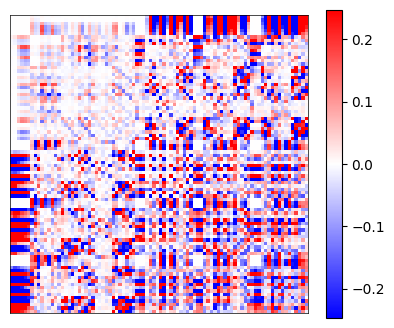

0.2465419854449029

In [126]:
matshow(H-ham)

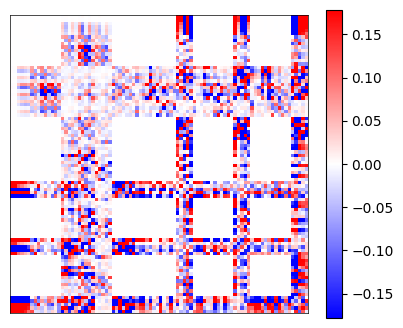

0.17832840956240037

In [129]:
matshow(H_t-ham)

In [117]:
def _matrix_transform_single(hamiltonian, atoms, convention_rule):
    """Transform matrices according to orbital convention using PyTorch.
    
    This function reorders and applies sign changes to orbital matrices based on
    different quantum chemistry software conventions. Different software packages
    use different orbital ordering and sign conventions.
    
    Example:
        Transform from 6-31G to def2-SVP convention:
        - 6-31G: p orbitals ordered as [px, py, pz] 
        - def2-SVP: p orbitals ordered as [py, pz, px]
        - This function handles the reordering and sign changes
    
    Args:
        hamiltonian (torch.Tensor): Input matrices to transform, shape (..., n_orb, n_orb).
        atoms (torch.Tensor): Atomic numbers for the molecule (e.g., [6, 1, 1, 1] for CH3).
        convention_rule (Namespace): Orbital convention to use:
            - 'pyscf_def2-tzvp': def2-TZVP basis set convention (p: [pz, px, py])
            - 'pyscf_631G': 6-31G basis set convention (p: [pz, px, py])
            - 'pyscf_def2svp': def2-SVP basis set convention (p: [py, pz, px])
            - 'back2pyscf': Convert back to PySCF native convention (p: [pz, px, py])
              * Use this when you have matrices from other software and need to
                convert them back to PySCF format for density matrix calculations
              * Same basis as def2-SVP but with PySCF's native p-orbital ordering
    
    Returns:
        torch.Tensor: Transformed matrices with reordered orbitals and applied sign changes.
    """
    conv = convention_rule
    
    # Get device from hamiltonian tensor
    device = hamiltonian.device
    dtype = hamiltonian.dtype
    
    orbitals = ""
    orbitals_order = []
    for a in atoms:
        offset = len(orbitals_order)
        orbitals += conv.atom_to_orbitals_map[a.item()]
        orbitals_order += [idx + offset for idx in conv.orbital_order_map[a.item()]]

    transform_indices = []
    transform_signs = []
    for orb in orbitals:
        offset = sum(map(len, transform_indices))
        map_idx = conv.orbital_idx_map[orb]
        map_sign = conv.orbital_sign_map[orb]
        # Convert to torch tensors directly on the correct device
        transform_indices.append(torch.tensor(map_idx, device=device, dtype=torch.long) + offset)
        transform_signs.append(torch.tensor(map_sign, device=device, dtype=dtype))

    # Reorder according to orbitals_order
    transform_indices = [transform_indices[idx] for idx in orbitals_order]
    transform_signs = [transform_signs[idx] for idx in orbitals_order]
    
    # Concatenate using torch.cat instead of np.concatenate
    transform_indices = torch.cat(transform_indices)
    transform_signs = torch.cat(transform_signs)
    
    # Apply transformation using torch indexing
    hamiltonian_new = hamiltonian[..., transform_indices, :]
    hamiltonian_new = hamiltonian_new[..., :, transform_indices]
    
    print(transform_indices)
    
    # Apply signs using torch operations
    hamiltonian_new = hamiltonian_new * transform_signs.unsqueeze(-1)
    hamiltonian_new = hamiltonian_new * transform_signs.unsqueeze(-2)

    return hamiltonian_new

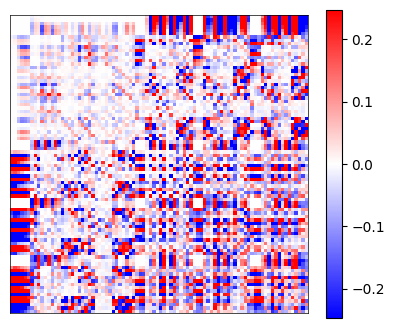

0.2465419854449029

In [118]:
matshow(ham-H)

In [62]:
H.shape

(88, 88)

In [51]:
import os, sys
sys.path.append("/root/25DFT/QHFlow/src")
from common.dft_utils import calc_overlap_and_init_hamiltonian, calc_dm0

ovlp, init_ham, mf = calc_overlap_and_init_hamiltonian(
    atomic_number,
    pos.reshape(-1, 3),
    unit="ang",
    out_mf=True,
    basis="def2-tzvppd",
    # xc="ωB97M-D3BJ",
    xc="wb97m-D3BJ",
)

In [54]:
mf.kernel()

-56.596332706894664

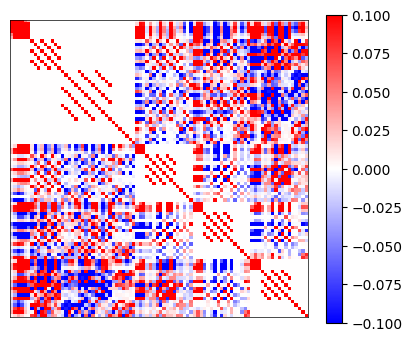

0.10000000000000005

In [26]:
matshow(ovlp)

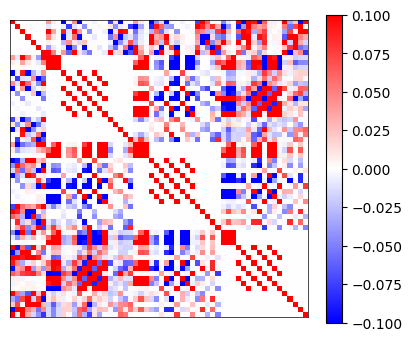

0.10000000000000014

In [34]:
matshow(S[30:,30:])

In [31]:
ovlp.sum()

232.33886069470591

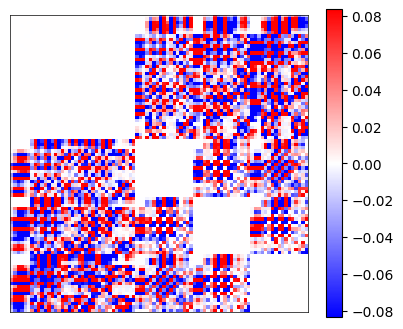

0.08372599262608998

In [55]:
matshow(S-mf.get_ovlp())

In [ ]:
#eigenvalue of S
eig_S = np.linalg.eigvals(S)
eig_ovlp = np.linalg.eigvals(ovlp)

In [42]:
print(eig_S)
print(eig_ovlp)
print(eig_S-eig_ovlp)

[3.95075896e-04 4.70945102e-04 4.71034531e-04 1.04171863e-03
 1.94146379e-03 1.94175080e-03 5.80508952e-03 2.23112481e-02
 2.23142143e-02 3.00404539e-02 4.13615498e-02 4.19115937e-02
 4.19176801e-02 4.71751766e-02 4.71807166e-02 4.99223887e-02
 5.19651321e-02 5.62222063e-02 5.62243666e-02 8.95233319e-02
 8.95397336e-02 9.93488552e-02 1.30705962e-01 1.30709924e-01
 1.36853646e-01 1.80902012e-01 1.83820430e-01 1.83826428e-01
 2.27614174e-01 2.27620412e-01 2.35129848e-01 2.43898565e-01
 2.43900833e-01 2.57790020e-01 2.67379419e-01 2.98808447e-01
 3.16341048e-01 3.16354701e-01 3.23742598e-01 4.02019805e-01
 4.02029187e-01 4.62027804e-01 4.86224769e-01 4.86248826e-01
 6.17264856e-01 6.84529879e-01 6.84536035e-01 7.79509608e-01
 7.91367313e-01 7.91371251e-01 8.57410606e-01 8.57430017e-01
 8.68998304e-01 8.90359467e-01 9.16432068e-01 9.16434303e-01
 1.01375846e+00 1.01377367e+00 1.04451713e+00 1.14684904e+00
 1.14690548e+00 1.15909916e+00 1.19497775e+00 1.21124724e+00
 1.32412445e+00 1.324155

In [44]:
# print(np.sort(eig_S))
# print(np.sort(eig_ovlp))
print(np.sort(eig_S)-np.sort(eig_ovlp))

[ 8.11916073e-13  1.09138973e-12  1.09149977e-12  2.09730931e-12
  3.93994169e-12  3.93944512e-12  1.14874863e-12  2.27305223e-11
  2.27337073e-11  2.64011313e-11  6.17210796e-11  4.57072089e-11
  4.57157645e-11  8.23652743e-11  8.23785207e-11  7.31190802e-11
  1.06980910e-10  7.09005771e-11  7.09078560e-11  1.62998309e-10
  1.63020125e-10  1.27843430e-10  2.19106261e-10  2.19100377e-10
  1.53994678e-10  3.18544885e-10  4.50390558e-11  4.50339210e-11
  3.43818085e-10  3.43675005e-10  7.22821247e-11  1.73258158e-10
  1.73126902e-10  1.04129427e-10  3.55993235e-10  1.58213775e-10
  1.33768108e-10  1.33636713e-10  8.17673707e-11  2.79423096e-10
  2.79366197e-10  4.66793160e-10  4.63745042e-10  4.63830585e-10
  5.70313796e-10  4.87981988e-10  4.87978324e-10  5.56074076e-11
  2.85267365e-11  2.85111934e-11  1.16721854e-10  1.16692989e-10
 -4.86126694e-11  3.77871845e-10  2.38966069e-10  2.38932651e-10
  1.07960307e-11  1.08144604e-11  4.83391105e-13  3.07425196e-10
  3.07336823e-10  3.87163

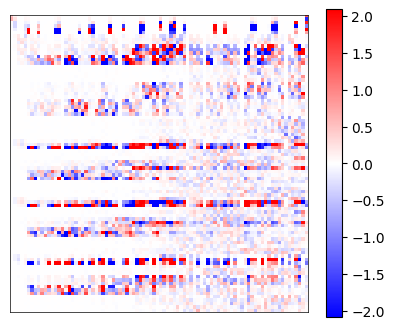

2.092651713680758

In [24]:
matshow(C)

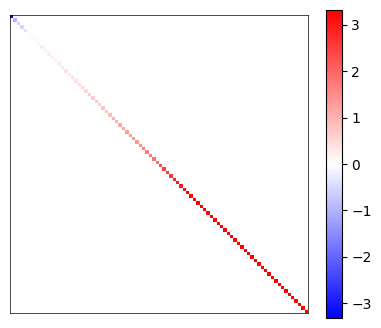

3.312403048943766

In [25]:
matshow(E_d)